# Workshop — VAE on MNIST


## 0. Setup + hyperparameters

In [ ]:

# !pip -q install torch torchvision

import os, math, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Hyperparams
latent_dim = 16
batch_size = 128
lr = 1e-3

# Keep workshop fast
train_subset = 10000   # set None for full MNIST (60000)

# Train lengths (VAE is the focus)
epochs_vae = 5         # try 1–10
epochs_ae  = 2         # baseline only (keep small)

beta = 1.0             # beta-VAE knob: 0.1 / 1.0 / 4.0


Device: cpu


## 1. Data (MNIST)

In [ ]:

transform = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

if train_subset is not None:
    idx = list(range(len(train_ds)))
    random.shuffle(idx)
    train_ds = Subset(train_ds, idx[:train_subset])

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

x0, y0 = next(iter(train_loader))
print("Batch:", x0.shape, "Labels:", y0[:10].tolist())


100%|██████████| 9.91M/9.91M [00:00<00:00, 63.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.69MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.31MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch: torch.Size([128, 1, 28, 28]) Labels: [3, 5, 8, 0, 0, 9, 8, 9, 7, 2]


## 2. VAE (main)

### 2.1 Model

Encoder outputs $\mu(x), \log \sigma^2(x)$.  
We sample with the reparameterization trick:

$$z = \mu + \sigma \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I), \quad \sigma = \exp(0.5\,\log \sigma^2)$$


In [ ]:

class VAE(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        # TODO

    def encode(self, x):
        # TODO

    def reparameterize(self, mu, logvar):
        # z = mu + sigma * eps
        # TODO

    def decode(self, z):
        # TODO

    def forward(self, x):
        # TODO
        return x_hat, mu, logvar, z

vae = VAE(latent_dim).to(device)
opt_vae = torch.optim.Adam(vae.parameters(), lr=lr)
print(vae)


VAE(
  (enc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU(inplace=True)
  )
  (fc_mu): Linear(in_features=256, out_features=16, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=16, bias=True)
  (dec): Sequential(
    (0): Linear(in_features=16, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


### 2.2 ELBO loss (where the KL code comes from)

We optimise the **negative ELBO** (per batch):

$$\mathcal{L}_{\text{VAE}} = \underbrace{\text{Recon}(x, \hat{x})}_{-\log p_\theta(x\mid z)} + \beta\,\underbrace{\text{KL}\big(q_\phi(z\mid x)\,\Vert\,\mathcal{N}(0,I)\big)}_{\text{regulariser}}$$

For diagonal Gaussians, the KL has a closed form. In code you often see:

```python
-0.5 * sum(1 + logvar - mu**2 - exp(logvar))
```

That's exactly $\text{KL}(\mathcal{N}(\mu, \sigma^2)\,\Vert\,\mathcal{N}(0,1))$ summed over latent dims and batch.


In [ ]:

def vae_loss(x_hat, x, mu, logvar, beta=1.0):
    # Reconstruction loss
    # Using BCE because pixels are in [0,1] and decoder ends with Sigmoid
    recon = # TODO  # sum over pixels and batch

    # KL divergence to N(0,1), summed over batch and dims
    kl = # TODO

    # Normalize by batch size so numbers are comparable
    bs = x.size(0)
    return recon/bs, kl/bs, (recon + beta*kl)/bs

def train_vae_one_epoch(model, loader, optim):
    model.train()
    recon_total = 0.0
    kl_total = 0.0
    loss_total = 0.0
    n = 0
    for x, _ in loader:
        x = x.to(device)
        x_hat, mu, logvar, _ = model(x)
        recon, kl, loss = vae_loss(x_hat, x, mu, logvar, beta=beta)

        optim.zero_grad(set_to_none=True)
        loss.backward()
        optim.step()

        bs = x.size(0)
        recon_total += recon.item() * bs
        kl_total += kl.item() * bs
        loss_total += loss.item() * bs
        n += bs
    return recon_total/n, kl_total/n, loss_total/n

@torch.no_grad()
def eval_vae(model, loader):
    model.eval()
    recon_total = 0.0
    kl_total = 0.0
    loss_total = 0.0
    n = 0
    for x, _ in loader:
        x = x.to(device)
        x_hat, mu, logvar, _ = model(x)
        recon, kl, loss = vae_loss(x_hat, x, mu, logvar, beta=beta)
        bs = x.size(0)
        recon_total += recon.item() * bs
        kl_total += kl.item() * bs
        loss_total += loss.item() * bs
        n += bs
    return recon_total/n, kl_total/n, loss_total/n

recon_hist, kl_hist, loss_hist = [], [], []
recon_te_hist, kl_te_hist, loss_te_hist = [], [], []

for ep in range(1, epochs_vae + 1):
    r, k, l = train_vae_one_epoch(vae, train_loader, opt_vae)
    rt, kt, lt = eval_vae(vae, test_loader)
    recon_hist.append(r); kl_hist.append(k); loss_hist.append(l)
    recon_te_hist.append(rt); kl_te_hist.append(kt); loss_te_hist.append(lt)
    print(f"[VAE] Epoch {ep:02d} | recon {r:.3f} | kl {k:.3f} | loss {l:.3f} || test loss {lt:.3f}")


[VAE] Epoch 01 | recon 232.617 | kl 2.108 | loss 234.725 || test loss 199.708
[VAE] Epoch 02 | recon 188.365 | kl 3.710 | loss 192.075 || test loss 183.423
[VAE] Epoch 03 | recon 165.938 | kl 7.648 | loss 173.585 || test loss 161.727
[VAE] Epoch 04 | recon 142.475 | kl 11.262 | loss 153.737 || test loss 147.183
[VAE] Epoch 05 | recon 130.652 | kl 12.612 | loss 143.264 || test loss 139.245


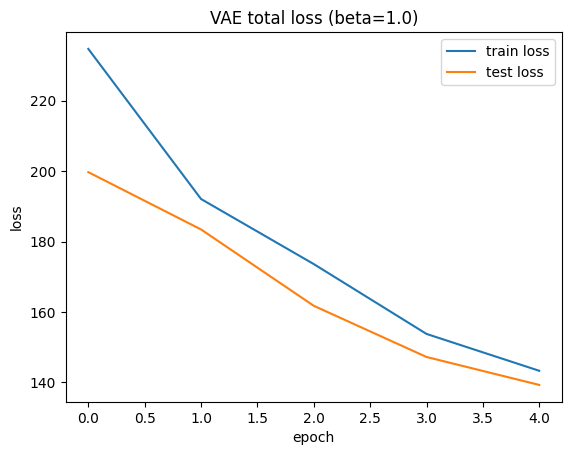

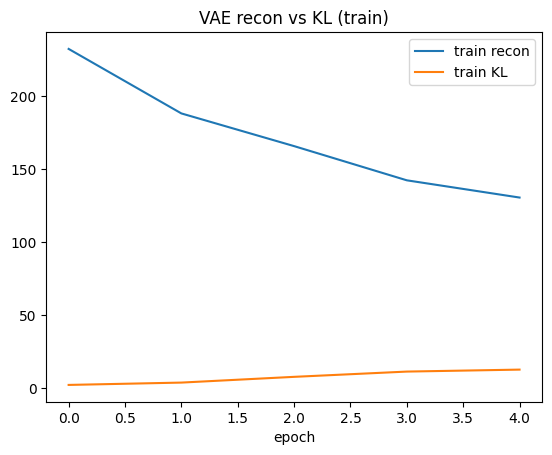

In [ ]:

# Plot training curves
plt.figure()
plt.plot(loss_hist, label="train loss")
plt.plot(loss_te_hist, label="test loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend()
plt.title(f"VAE total loss (beta={beta})")
plt.show()

plt.figure()
plt.plot(recon_hist, label="train recon")
plt.plot(kl_hist, label="train KL")
plt.xlabel("epoch"); plt.legend()
plt.title("VAE recon vs KL (train)")
plt.show()


### 2.3 VAE: reconstructions / random sampling / interpolation

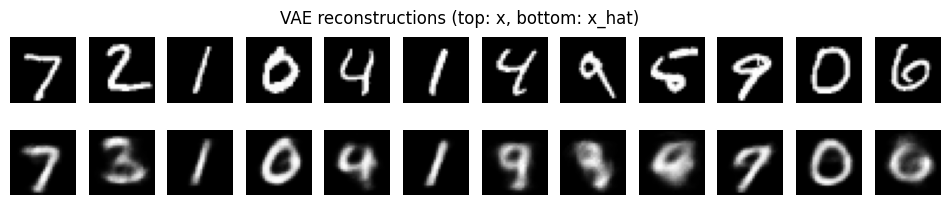

In [ ]:

@torch.no_grad()
def show_reconstructions_vae(model, loader, n=12):
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(device)[:n]
    x_hat, _, _, _ = model(x)

    x = x.cpu()
    x_hat = x_hat.cpu()

    plt.figure(figsize=(n, 2.2))
    for i in range(n):
        ax = plt.subplot(2, n, i+1)
        ax.imshow(x[i,0], cmap="gray"); ax.axis("off")
        ax = plt.subplot(2, n, n+i+1)
        ax.imshow(x_hat[i,0], cmap="gray"); ax.axis("off")
    plt.suptitle("VAE reconstructions (top: x, bottom: x_hat)")
    plt.show()

show_reconstructions_vae(vae, test_loader)


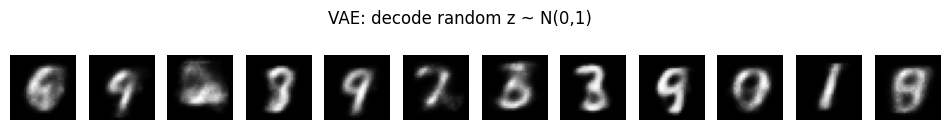

In [ ]:

@torch.no_grad()
def show_random_samples_vae(model, n=12):
    model.eval()
    z = torch.randn(n, latent_dim, device=device)
    x_gen = model.decode(z).cpu()

    plt.figure(figsize=(n, 1.6))
    for i in range(n):
        ax = plt.subplot(1, n, i+1)
        ax.imshow(x_gen[i,0], cmap="gray"); ax.axis("off")
    plt.suptitle("VAE: decode random z ~ N(0,1)")
    plt.show()

show_random_samples_vae(vae, n=12)


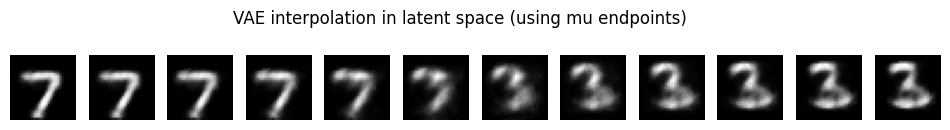

In [ ]:

@torch.no_grad()
def latent_interpolation_vae_mu(model, loader, steps=12):
    model.eval()
    x, y = next(iter(loader))
    x = x.to(device)

    # pick two different labels
    a = 0
    b = 1
    while y[b].item() == y[a].item():
        b += 1

    xa = x[a:a+1]
    xb = x[b:b+1]

    mu_a, _ = model.encode(xa)
    mu_b, _ = model.encode(xb)

    alphas = torch.linspace(0, 1, steps, device=device).view(-1, 1)
    z = (1 - alphas) * mu_a + alphas * mu_b
    x_gen = model.decode(z).cpu()

    plt.figure(figsize=(steps, 1.6))
    for i in range(steps):
        ax = plt.subplot(1, steps, i+1)
        ax.imshow(x_gen[i,0], cmap="gray"); ax.axis("off")
    plt.suptitle("VAE interpolation in latent space (using mu endpoints)")
    plt.show()

latent_interpolation_vae_mu(vae, test_loader, steps=12)


## 3. AE baseline (for comparison only)

### 3.1 AE model

Important conceptual difference:

- **VAE** explicitly trains a latent distribution close to $\mathcal{N}(0,I)$, so sampling random $z$ is meaningful.
- **AE** has *no constraint* on where latent codes live. Decoding a random $z\sim\mathcal{N}(0,I)$ is usually garbage unless by luck it matches the latent code manifold.

We'll train an AE quickly, then compare **three generation strategies**:
1. `AE decode(z ~ N(0,1))` (often bad)
2. `AE decode(z = encoder(x))` for random training images (this is basically reconstruction)
3. `AE decode(z ~ fitted Gaussian)` where we fit $\mu,\Sigma$ to encoded training latents (a common hack)


In [ ]:

class AE(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 28*28),
            nn.Sigmoid(),
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        x_hat = self.decoder(z)
        return x_hat.view(-1, 1, 28, 28)

    def forward(self, x):
        z = self.encode(x)
        x_hat = self.decode(z)
        return x_hat, z

ae = AE(latent_dim).to(device)
opt_ae = torch.optim.Adam(ae.parameters(), lr=lr)
print(ae)


AE(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU(inplace=True)
    (5): Linear(in_features=256, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


[AE]  Epoch 01 | train BCE 0.3019 | test BCE 0.2452
[AE]  Epoch 02 | train BCE 0.2205 | test BCE 0.1922


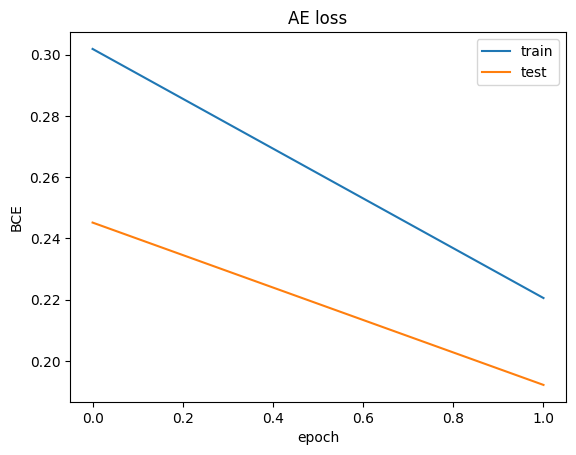

In [ ]:

def train_ae_one_epoch(model, loader, optim):
    model.train()
    total = 0.0
    n = 0
    for x, _ in loader:
        x = x.to(device)
        x_hat, _ = model(x)
        loss = F.binary_cross_entropy(x_hat, x, reduction="mean")

        optim.zero_grad(set_to_none=True)
        loss.backward()
        optim.step()

        total += loss.item() * x.size(0)
        n += x.size(0)
    return total / n

@torch.no_grad()
def eval_ae(model, loader):
    model.eval()
    total = 0.0
    n = 0
    for x, _ in loader:
        x = x.to(device)
        x_hat, _ = model(x)
        loss = F.binary_cross_entropy(x_hat, x, reduction="mean")
        total += loss.item() * x.size(0)
        n += x.size(0)
    return total / n

train_hist, test_hist = [], []
for ep in range(1, epochs_ae + 1):
    tr = train_ae_one_epoch(ae, train_loader, opt_ae)
    te = eval_ae(ae, test_loader)
    train_hist.append(tr); test_hist.append(te)
    print(f"[AE]  Epoch {ep:02d} | train BCE {tr:.4f} | test BCE {te:.4f}")

plt.figure()
plt.plot(train_hist, label="train")
plt.plot(test_hist, label="test")
plt.xlabel("epoch"); plt.ylabel("BCE"); plt.legend()
plt.title("AE loss")
plt.show()


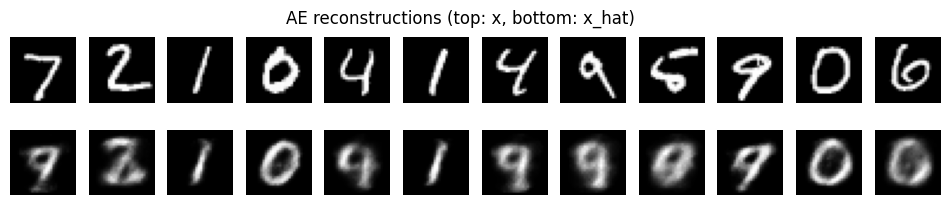

In [ ]:

@torch.no_grad()
def show_reconstructions_ae(model, loader, n=12):
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(device)[:n]
    x_hat, _ = model(x)

    x = x.cpu()
    x_hat = x_hat.cpu()

    plt.figure(figsize=(n, 2.2))
    for i in range(n):
        ax = plt.subplot(2, n, i+1)
        ax.imshow(x[i,0], cmap="gray"); ax.axis("off")
        ax = plt.subplot(2, n, n+i+1)
        ax.imshow(x_hat[i,0], cmap="gray"); ax.axis("off")
    plt.suptitle("AE reconstructions (top: x, bottom: x_hat)")
    plt.show()

show_reconstructions_ae(ae, test_loader)


### 3.2 AE random generation: three strategies

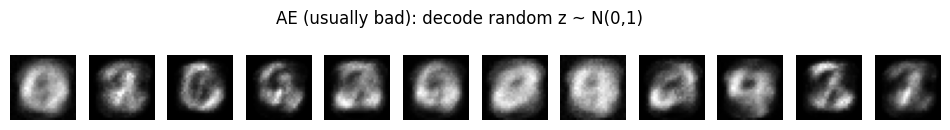

In [ ]:

@torch.no_grad()
def show_random_decode_standard_normal_ae(model, n=12):
    model.eval()
    z = torch.randn(n, latent_dim, device=device)
    x_gen = model.decode(z).cpu()

    plt.figure(figsize=(n, 1.6))
    for i in range(n):
        ax = plt.subplot(1, n, i+1)
        ax.imshow(x_gen[i,0], cmap="gray"); ax.axis("off")
    plt.suptitle("AE (usually bad): decode random z ~ N(0,1)")
    plt.show()

show_random_decode_standard_normal_ae(ae, n=12)


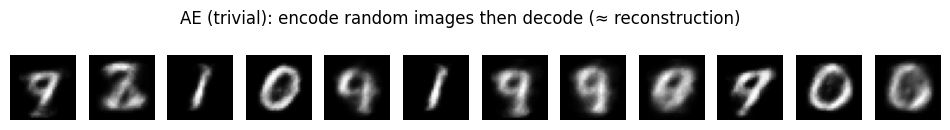

In [ ]:

@torch.no_grad()
def show_decode_of_encoded_images_ae(model, loader, n=12):
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(device)[:n]
    z = model.encode(x)
    x_gen = model.decode(z).cpu()

    plt.figure(figsize=(n, 1.6))
    for i in range(n):
        ax = plt.subplot(1, n, i+1)
        ax.imshow(x_gen[i,0], cmap="gray"); ax.axis("off")
    plt.suptitle("AE (trivial): encode random images then decode (≈ reconstruction)")
    plt.show()

show_decode_of_encoded_images_ae(ae, test_loader, n=12)


Fitted latent mean shape: (16,) cov shape: (16, 16)


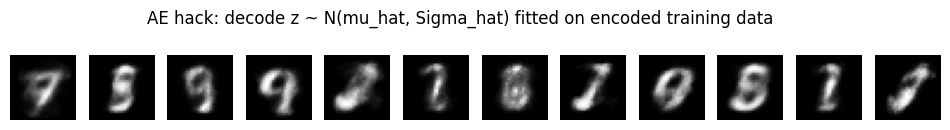

In [ ]:

@torch.no_grad()
def fit_gaussian_to_latents(model, loader, max_batches=100):
    """Fit a full-cov Gaussian to AE latents: z ~ N(mu_hat, Sigma_hat)."""
    model.eval()
    Z = []
    for i, (x, _) in enumerate(loader):
        if i >= max_batches:
            break
        x = x.to(device)
        z = model.encode(x).detach().cpu().numpy()
        Z.append(z)
    Z = np.concatenate(Z, axis=0)  # [N, latent_dim]
    mu_hat = Z.mean(axis=0)
    # Add a tiny ridge for numerical stability
    Sigma_hat = np.cov(Z, rowvar=False) + 1e-4*np.eye(Z.shape[1])
    return mu_hat, Sigma_hat

mu_hat, Sigma_hat = fit_gaussian_to_latents(ae, train_loader, max_batches=100)
print("Fitted latent mean shape:", mu_hat.shape, "cov shape:", Sigma_hat.shape)

@torch.no_grad()
def show_random_samples_ae_fitted_gaussian(model, n=12):
    model.eval()
    z = np.random.multivariate_normal(mu_hat, Sigma_hat, size=n).astype(np.float32)
    z = torch.from_numpy(z).to(device)
    x_gen = model.decode(z).cpu()

    plt.figure(figsize=(n, 1.6))
    for i in range(n):
        ax = plt.subplot(1, n, i+1)
        ax.imshow(x_gen[i,0], cmap="gray"); ax.axis("off")
    plt.suptitle("AE hack: decode z ~ N(mu_hat, Sigma_hat) fitted on encoded training data")
    plt.show()

show_random_samples_ae_fitted_gaussian(ae, n=12)


### 3.3 AE latent interpolation

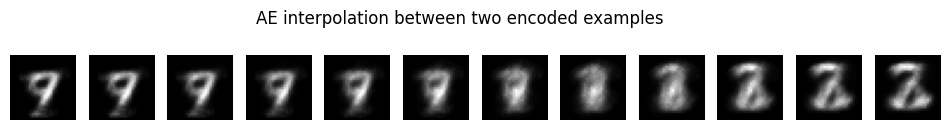

In [ ]:

@torch.no_grad()
def latent_interpolation_ae(model, loader, steps=12):
    model.eval()
    x, y = next(iter(loader))
    x = x.to(device)

    a = 0
    b = 1
    while y[b].item() == y[a].item():
        b += 1

    xa = x[a:a+1]
    xb = x[b:b+1]
    za = model.encode(xa)
    zb = model.encode(xb)

    alphas = torch.linspace(0, 1, steps, device=device).view(-1, 1)
    z = (1 - alphas) * za + alphas * zb
    x_gen = model.decode(z).cpu()

    plt.figure(figsize=(steps, 1.6))
    for i in range(steps):
        ax = plt.subplot(1, steps, i+1)
        ax.imshow(x_gen[i,0], cmap="gray"); ax.axis("off")
    plt.suptitle("AE interpolation between two encoded examples")
    plt.show()

latent_interpolation_ae(ae, test_loader, steps=12)


## 4. Side-by-side comparison (VAE vs AE)

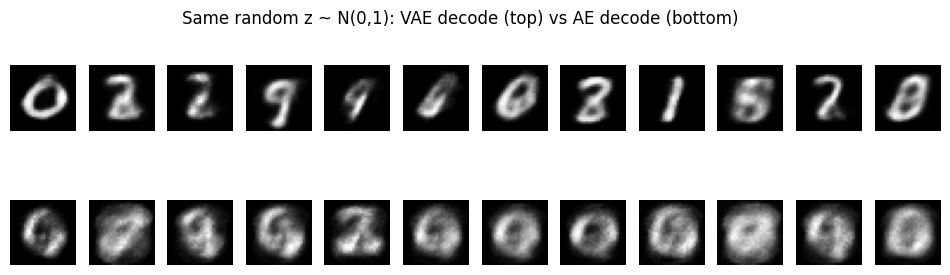

In [ ]:

@torch.no_grad()
def compare_random_generation(vae, ae, n=12):
    vae.eval(); ae.eval()
    z = torch.randn(n, latent_dim, device=device)
    x_vae = vae.decode(z).cpu()
    x_ae  = ae.decode(z).cpu()

    plt.figure(figsize=(n, 3.2))
    for i in range(n):
        ax = plt.subplot(2, n, i+1)
        ax.imshow(x_vae[i,0], cmap="gray"); ax.axis("off")
        ax = plt.subplot(2, n, n+i+1)
        ax.imshow(x_ae[i,0], cmap="gray"); ax.axis("off")
    plt.suptitle("Same random z ~ N(0,1): VAE decode (top) vs AE decode (bottom)")
    plt.show()

compare_random_generation(vae, ae, n=12)


## 5. What to try

1. Change `beta` to `0.1`, `1.0`, `4.0` and retrain only the VAE:
   - lower beta → sharper recon, weaker latent regularisation
   - higher beta → nicer samples, blurrier recon

2. Increase `latent_dim` to 2 or 8 and:
   - visualise interpolation
   - see how sample quality changes

3. Make AE training longer (`epochs_ae = 10`) and see if the Gaussian-fit sampling gets better.
